<a href="https://colab.research.google.com/github/sebaspatric/curso-no-parametrica/blob/main/7.%20Correlaci%C3%B3n%20rho%20Spearman/7.3%20Ejemplo%202%20Python/7_3_Spearman2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.stats.diagnostic import normal_ad
from scipy.stats import shapiro
import seaborn as sns

In [12]:
link="https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/main/7.%20Correlación%20rho%20Spearman/7.3%20Ejemplo%202%20Python/pinetree.csv"

In [14]:
import pandas as pd

link="https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/main/7.%20Correlaci%C3%B3n%20rho%20Spearman/7.3%20Ejemplo%202%20Python/pinetree.csv"

df = pd.read_csv(link)
df.head()

,pine_population,beetle_density
0,896.106591,0.090259
1,884.237630,0.223759
2,830.827303,0.311749
3,860.499707,0.796264
4,961.385880,0.543835


In [15]:
from urllib.parse import quote

ruta = "7. Correlación rho Spearman/7.3 Ejemplo 2 Python/pinetree.csv"

print(quote(ruta))

7.%20Correlaci%C3%B3n%20rho%20Spearman/7.3%20Ejemplo%202%20Python/pinetree.csv


In [16]:
df = pd.read_csv(link)
df.head()

,pine_population,beetle_density
0,896.106591,0.090259
1,884.237630,0.223759
2,830.827303,0.311749
3,860.499707,0.796264
4,961.385880,0.543835


In [ ]:

#df=pd.read_csv('/content/pinetree.csv')
#df.head()

,pine_population,beetle_density
0,896.106591,0.090259
1,884.237630,0.223759
2,830.827303,0.311749
3,860.499707,0.796264
4,961.385880,0.543835


# Normalidad de los residuos

In [17]:
import statsmodels.formula.api as smf
#instantiation
reg = smf.ols('pine_population ~ beetle_density', data = df)
#members of reg object
print(dir(reg))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_kwargs', '_data_attr', '_df_model', '_df_resid', '_fit_collinear', '_fit_ridge', '_fit_zeros', '_formula_max_endog', '_get_init_kwds', '_handle_data', '_init_keys', '_kwargs_allowed', '_setup_score_hess', '_sqrt_lasso', 'data', 'df_model', 'df_resid', 'endog', 'endog_names', 'exog', 'exog_names', 'fit', 'fit_regularized', 'formula', 'from_formula', 'get_distribution', 'hessian', 'hessian_factor', 'information', 'initialize', 'k_constant', 'loglike', 'nobs', 'pinv_wexog', 'predict', 'rank', 'score', 'weights', 'wendog', 'wexog', 'whiten']


In [18]:
res = reg.fit()

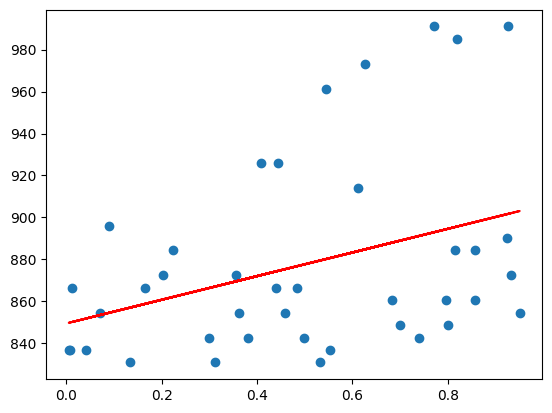

In [19]:
plt.scatter(df.beetle_density, df.pine_population)
plt.plot(df.beetle_density, res.fittedvalues, color='red')
plt.show()

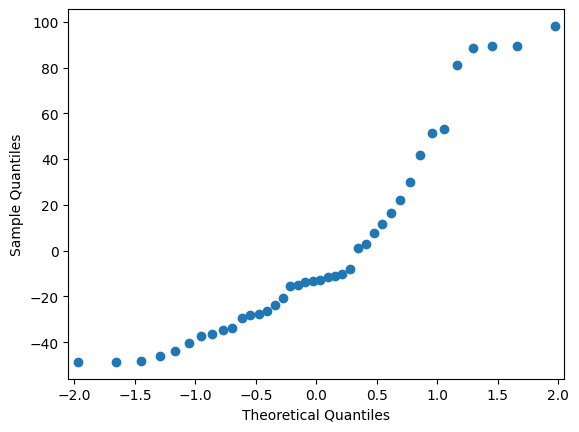

In [20]:
import statsmodels.api as sm
sm.qqplot(res.resid);

Assumption: The error terms are normally distributed 

Using the Anderson-Darling test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 7.951116410427978e-05
Residuals are not normally distributed 

Using the Shapiro-Wilks test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 0.00022804022081376313
Residuals are not normally distributed


/tmp/ipykernel_2274/1166590315.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res.resid)


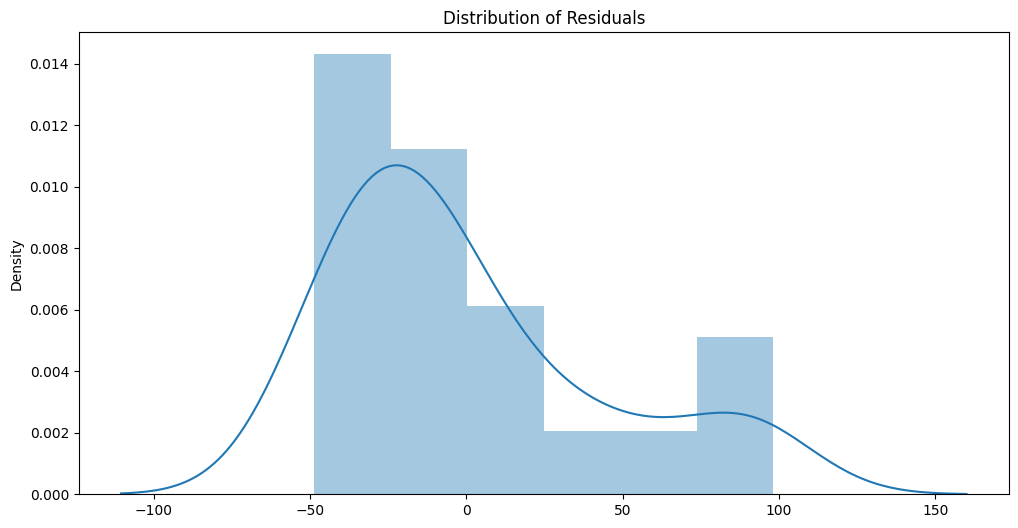


Assumption not satisfied

Confidence intervals will likely be affected
Try performing nonlinear transformations on variables


In [21]:
    print('Assumption: The error terms are normally distributed', '\n')

    p_value_thresh=0.05
    print('Using the Anderson-Darling test for normal distribution')

    # Performing the test on the residuals
    p_value = normal_ad(res.resid)[1]
    print('p-value from the test - below 0.05 generally means non-normal:', p_value)

    # Reporting the normality of the residuals
    if p_value < p_value_thresh:
        print('Residuals are not normally distributed', '\n')
    else:
        print('Residuals are normally distributed', '\n')

    print('Using the Shapiro-Wilks test for normal distribution')
    shapiro_test = shapiro(res.resid)
    shapiro_test_stat=shapiro_test[0]
    shapiro_test_pvalue=shapiro_test[1]
    print('p-value from the test - below 0.05 generally means non-normal:', shapiro_test_pvalue)

    # Reporting the normality of the residuals
    if shapiro_test_pvalue < p_value_thresh:
        print('Residuals are not normally distributed')
    else:
        print('Residuals are normally distributed')

    # Plotting the residuals distribution
    plt.subplots(figsize=(12, 6))
    plt.title('Distribution of Residuals')
    sns.distplot(res.resid)
    plt.show()

    print()
    if p_value > p_value_thresh:
        print('Assumption satisfied')
    else:
        print('Assumption not satisfied')
        print()
        print('Confidence intervals will likely be affected')
        print('Try performing nonlinear transformations on variables')

In [22]:
corr, p = stats.spearmanr(df.pine_population, df.beetle_density)

print('Correlation=%.3f, p=%.3f' % (corr, p))
# interpretación
alpha = 0.05
if p > alpha:
	print('No rechazamos H0: Correlación no significativa.')
else:
	print('Rechazamos H0: Correlación significativa.')

Correlation=0.367, p=0.020
Rechazamos H0: Correlación significativa.
